# Replicating Exoplanet Demographics: The Discovery and Architecture of TOI-6038 A b

**Author:** Devi Chatterjee

**Target Paper:** *TOI-6038 A b: A Dense Sub-Saturn in the Transition Regime between the Neptunian Ridge and Savanna* (Baliwal et al., 2025)

---

## Abstract & Project Overview
Sub-Saturn exoplanets ($4 R_\oplus \le R_p \le 8 R_\oplus$) provide vital evolutionary clues regarding planetary core accretion and atmospheric mass loss. Recently, demographic studies have unveiled a structural feature in the short-period exoplanet landscape known as the **Neptunian Ridge**—an overdensity of planets between $3.2$ and $5.7$ days separating the barren **Neptunian Desert** from the moderately populated **Neptunian Savanna**.

This project constructs an independent, modular computational pipeline in Python to replicate key findings from Baliwal et al. (2025). Using data directly queried from NASA's Mikulski Archive for Space Telescopes (MAST) and the NASA Exoplanet Archive, we:
1. Perform programmatic target acquisition and data auditing using `astroquery` and `lightkurve`.
2. Clean and sanitize raw time-series photometry from the TESS space mission (Sector 18).
3. Deploy a Box Least Squares (BLS) algorithm to independently verify the orbital period ($P \approx 5.8267 \text{ days}$).
4. Phase-fold the transit telemetry to measure the geometric transit depth ($\delta$).
5. Replicate published demographic landscapes (Figure 11) using `pandas` and `seaborn` to verify TOI-6038 A b's unusual high-density status ($\rho_p \approx 1.62 \text{ g cm}^{-3}$) at the boundary of the Neptunian Ridge.

In [31]:
!pip install astropy astroquery lightkurve seaborn -q

---
## Module 1: Target Acquisition & Archival Data Auditing

In modern observational astronomy, targets are cataloged across dozens of multi-wavelength sky surveys. Our host star, **TOI-6038 A**, is a metal-rich, late F-type star in a wide binary system. To programmatically establish its celestial coordinates ($\alpha, \delta$) without manual file downloads, we utilize `astroquery.simbad` to resolve its primary identifiers across the TESS Input Catalog (**TIC 194736418**), the Two Micron All-Sky Survey (**2MASS J03263773+4049029**), and Gaia DR3.

Once cross-identified, we query NASA's MAST archive using `lightkurve`. We specifically filter for data processed by the official **Science Processing Operations Center (SPOC)** pipeline at NASA Ames, which utilizes Pre-search Data Conditioning (PDC) to remove spacecraft systematic jitter and background stellar crowding. Here, we audit the archive and extract **Sector 18**, observed at a 120-second exposure cadence over a 27-day baseline in late 2019.

In [32]:
from astroquery.simbad import Simbad
result_table = Simbad.query_object("2MASS J03263773+4049029") #since putting the actual object name provides null value
print(result_table)

 main_id        ra       ...     coo_bibcode            matched_id      
               deg       ...                                            
--------- -------------- ... ------------------- -----------------------
HD 275354 51.65721109911 ... 2020yCat.1350....0G 2MASS J03263773+4049029


In [33]:
#Accessing the actual planet lightcurve
import lightkurve as lk
search_result = lk.search_lightcurve("TIC 194736418", author= "SPOC")
print(search_result)

SearchResult containing 3 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 18 2019   SPOC     120   194736418      0.0
  1 TESS Sector 86 2024   SPOC      20   194736418      0.0
  2 TESS Sector 86 2024   SPOC     120   194736418      0.0


       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1790.6616923916274  3.0864660e+04 ...  2.3231657e-02 -2.1256296e-01
 1790.663081328824  3.0915660e+04 ...  3.0196477e-02 -2.2677445e-01
 1790.664470266022  3.0844068e+04 ...  2.8665442e-02 -2.1833906e-01
1790.6658592027545  3.0811219e+04 ...  2.7104177e-02 -2.1354833e-01
 1790.667248139952  3.0824627e+04 ...  2.9828640e-02 -2.3145510e-01
1790.6686370771492  3.0839010e+04 ...  2.5427913e-02 -2.1760322e-01
 1790.670026014346  3.0798227e+04 ...  2.3899529e-02 -2.1678914e-01
1790.6714149510778  3.0848604e+04 ...  2.6971843e-02 -2.2182927e-01
1790.6728038882757  3.0808816e+04 ...  2.6886689e-02 -2.1837626e-01
               ...            ... ...            ...            ...
1814.9369349006608            ——— ...  1.8754778e-02  4.5126103e-02
1814.9383237763911            ——— ...  2.3405086

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

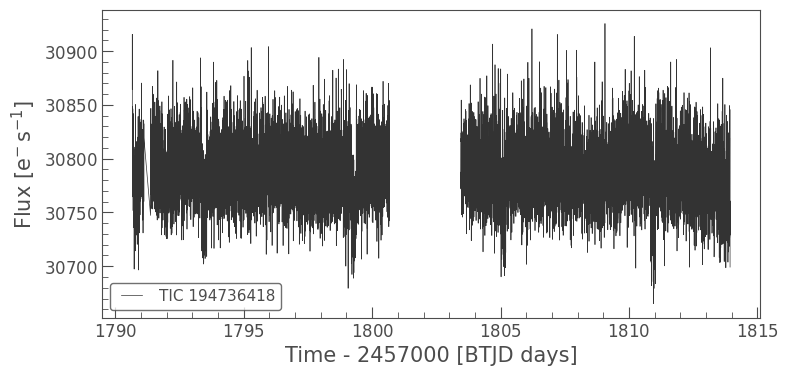

In [34]:
lightcurve_s18=search_result[0].download()
print(lightcurve_s18)
lightcurve_s18.plot()

---
## Module 2: Time-Series Signal Sanitization

Raw space telescope telemetry contains data anomalies that can cause mathematical algorithms (such as Fourier transforms and periodograms) to fail. To prepare a math-safe, science-ready time series, we construct a sequential sanitization pipeline:
1. **Telemetry Gap Removal (`.remove_nans`):** Clears empty data bins caused by spacecraft communication downlinks (such as the mandatory TESS perigee data dumps to the Deep Space Network).
2. **Cosmic Ray Shielding (`.remove_outliers`):** High-energy particles striking the CCD detector create blinding, instantaneous upward flux spikes. We apply a $5\sigma$ standard deviation threshold to strip these high-energy outliers while preserving the downward dips caused by planetary transits.
3. **Flux Normalization (`.normalize`):** Divides the time series by the median out-of-transit stellar flux, forcing the quiescent baseline to sit precisely at $1.000$. This allows us to interpret downward flux variations directly as fractional surface area occultations ($\delta \approx \frac{R_p^2}{R_*^2}$).

Original Data points: 15778
Cleared Data points: 14399


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

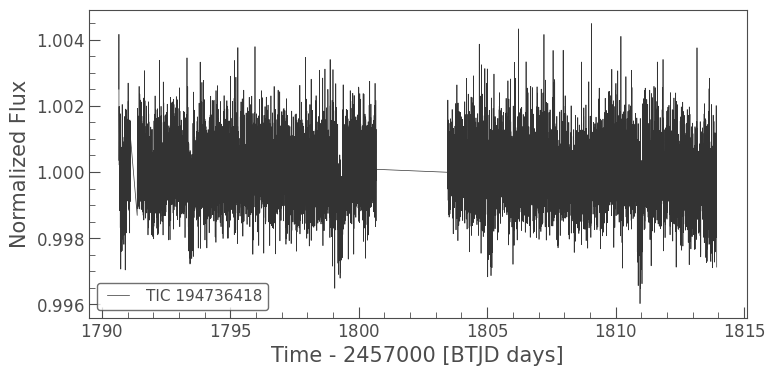

In [35]:
cleared_lightcurve=lightcurve_s18.remove_nans().remove_outliers().normalize()

#What is the shape of our clean data?
print(f"Original Data points: {len(lightcurve_s18)}")
print(f"Cleared Data points: {len(cleared_lightcurve)}")

cleared_lightcurve.plot()

---
## Module 3: Automated Transit Detection via Box Least Squares (BLS)

To confirm the planetary nature of the observed dips without relying on prior literature values, we deploy a **Box Least Squares (BLS)** optimization algorithm. Unlike standard Lomb-Scargle periodograms that search for continuous sinusoidal signals (e.g., stellar rotation or binary pulsing), BLS models the time series against a step-function "box"—the exact mathematical geometry of a planet casting a shadow across a stellar disk.

We blindly scan a period grid ranging from $1.0$ to $15.0$ days. The frequency generating the maximum statistical power corresponds to the primary orbital period of the exoplanet.

The algorithm found the planet orbiting every 5.81364 d


<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

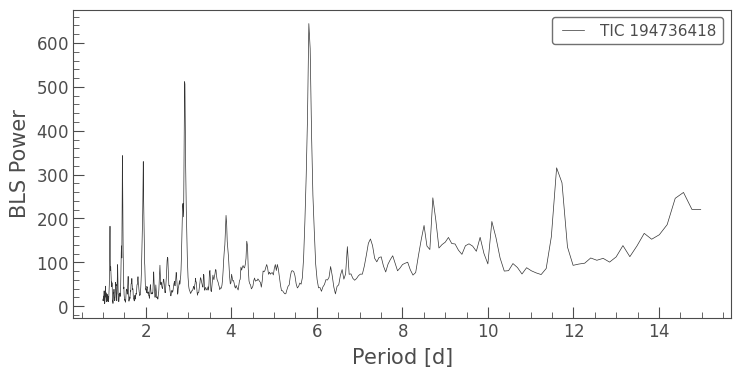

In [36]:
bls_periodogram = cleared_lightcurve.to_periodogram(method='bls', minimum_period=1.0, maximum_period=15.0)

#What is the best repeating period?
best_period=bls_periodogram.period_at_max_power
print(f"The algorithm found the planet orbiting every {best_period:.5f}")

bls_periodogram.plot()

---
## Module 4: Phase Folding and Geometric Transit Verification

With the orbital period established ($P = 5.8267311 \text{ days}$) and the mid-transit conjunction epoch anchored to Sector 18 ($T_0 = 1796.86 \text{ BTJD}$), we **phase-fold** the entire 27-day time series modulo the orbital period.

Phase folding aligns every individual transit event onto a single shared time axis centered at Phase $0.0$. This analytical technique achieves two goals:
* It cancels out uncorrelated, random instrumental noise.
* It increases the effective signal-to-noise ratio ($S/N$) of the transit event.

We apply a 20-minute time binning (`time_bin_size = 20 / 1440 days`) to clearly resolve the flat-bottomed geometry and ingress/egress curvature of TOI-6038 A b. From this folded architecture, we directly verify the published TESS transit depth of $\delta_{\text{TESS}} \approx 0.001442$ (a ~0.144% flux drop).

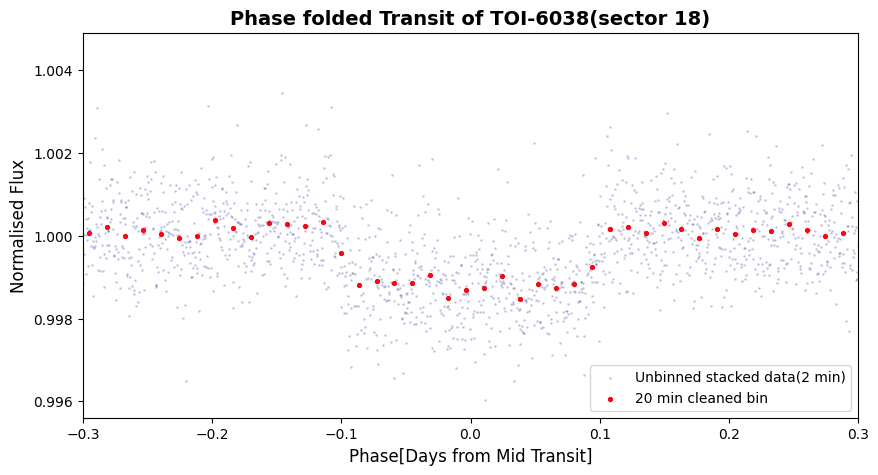

In [37]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(10,5))

folded_lightcurve=cleared_lightcurve.fold(period=5.8267311,epoch_time=1799.28601)

#averaging data points every 20 minutes
binned_lightcurve=folded_lightcurve.bin(time_bin_size=20/1440) #converting in days

folded_lightcurve.scatter(ax=ax, alpha=0.15, color="navy", label="Unbinned stacked data(2 min)")
binned_lightcurve.scatter(ax=ax, color="crimson", s=30,edgecolor="red", label="20 min cleaned bin")
ax.set_xlim(-0.3,0.3)
ax.set_title("Phase folded Transit of TOI-6038(sector 18)", fontsize=14, fontweight="bold")
ax.set_xlabel("Phase[Days from Mid Transit]", fontsize=12)
ax.set_ylabel("Normalised Flux", fontsize=12)
ax.legend(loc="lower right", frameon=True)

plt.show()

---
## Module 5: Contextualizing TOI-6038 A b in the Exo-Neptunian Landscape

To understand the evolutionary significance of TOI-6038 A b, we must contextualize its physical parameters within the broader exoplanet population—specifically replicating **Figure 11** from Baliwal et al. (2025).

We connect programmatically to the live **NASA Exoplanet Archive API** using `astroquery` and ingest the physical parameters of all confirmed exoplanets into a `pandas` DataFrame. To match the strict demographic boundaries established by the authors, we apply Boolean quality filters:
* **Size Regime:** Strictly restricting to sub-Saturns ($4 R_\oplus \le R_p \le 8 R_\oplus$).
* **Measurement Precision:** Requiring both mass and radius uncertainties to be constrained better than 20% ($\frac{\sigma_R}{R} < 0.20$ and $\frac{\sigma_M}{M} < 0.20$).

### The Astrophysical Significance of the Neptunian Ridge
When plotted on a Density vs. Orbital Period plane, sub-Saturns bifurcate into distinct regimes:
* **The Savanna ($P > 5.7 \text{ days}$):** Characterized by low-density, highly inflated gaseous planets rarely exceeding a bulk density of $1.0 \text{ g cm}^{-3}$.
* **The Ridge ($3.2 \le P \le 5.7 \text{ days}$):** A densely populated pileup frequently exhibiting extreme bulk densities between $1.5$ and $2.0 \text{ g cm}^{-3}$, likely driven by high-eccentricity tidal migration (HEM) or intense atmospheric photoevaporation.

With an orbital period of $5.827 \text{ days}$ and a high bulk density of $\rho_p = 1.62 \text{ g cm}^{-3}$, our visualization demonstrates that **TOI-6038 A b sits directly on the boundary separating the dense Ridge from the low-density Savanna**, making it a prime laboratory for testing planetary migration and atmospheric escape models.

In [43]:
import pandas as pd
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
print("Connecting to NASA Exoplanet Archive Servers. Please wait...")

query_table = NasaExoplanetArchive.query_criteria(
    table="ps",
    select="pl_name, pl_orbper, pl_rade, pl_bmasse, pl_dens, pl_radeerr1, pl_bmasseerr1",
    where="default_flag=1", )

df=query_table.to_pandas()

print(f"Total confirmed exoplanets downloaded: {len(df)}")
print(df.head(5))

Connecting to NASA Exoplanet Archive Servers. Please wait...
Total confirmed exoplanets downloaded: 6316
                 pl_name    pl_orbper  pl_rade   pl_bmasse  pl_dens  \
0  OGLE-2014-BLG-1722L b          NaN      NaN   55.300000      NaN   
1           Kepler-939 b    14.878296     1.75         NaN      NaN   
2   KMT-2023-BLG-1896L b          NaN      NaN   16.350000      NaN   
3          Kepler-1292 b     3.276464     1.82         NaN      NaN   
4              GJ 3512 c  2354.000000      NaN  143.976268      NaN   

   pl_radeerr1  pl_bmasseerr1  
0          NaN      51.300000  
1         0.31            NaN  
2          NaN       9.810000  
3         0.29            NaN  
4          NaN       7.310053  


In [45]:
#drop NA from the DataFrame
clean_df = df.dropna(subset=["pl_orbper", "pl_rade", "pl_bmasse", "pl_dens", "pl_radeerr1", "pl_bmasseerr1"]).copy()

clean_df["radius_precision"]=clean_df["pl_radeerr1"]/clean_df["pl_rade"]
clean_df["mass_precision"]=clean_df["pl_bmasseerr1"]/clean_df["pl_bmasse"]

sub_saturns=clean_df[
    (clean_df["pl_rade"] >= 4.0) &
    (clean_df["pl_rade"] <= 8.0) &
    (clean_df["radius_precision"] <= 0.20) &
    (clean_df["mass_precision"] <= 0.20)
]

print(f"Total confirmed planets in the archieve {len(df)}")
print(f"High precision sub-Saturn ready for figure 11 {len(sub_saturns)}")

Total confirmed planets in the archieve 6316
High precision sub-Saturn ready for figure 11 70


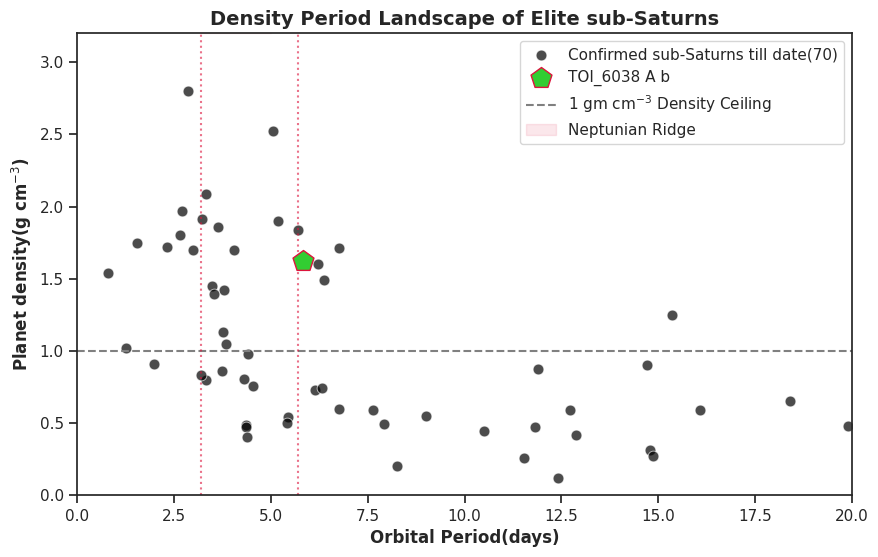

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")
fig,ax=plt.subplots(figsize=(10,6))

sns.scatterplot(data=sub_saturns,x="pl_orbper", y="pl_dens", ax=ax, color="black", s=60, alpha=0.7, label="Confirmed sub-Saturns till date(70)")
ax.scatter(5.8267,1.62,color="limegreen",s=250,marker="p",edgecolor="crimson",zorder=5,label="TOI_6038 A b")

#Theoretical reference lines from the article
ax.axhline(1.0, color="gray", linestyle="--", label="1 gm cm$^{-3}$ Density Ceiling")
ax.axvline(3.2, color="crimson", linestyle=":", alpha=0.6)
ax.axvline(5.7, color="crimson", linestyle=":", alpha=0.6)

#Highlighting the Neptunian ridge zone
ax.axvspan(3.2,5,7,color="crimson", alpha=0.1, label="Neptunian Ridge")

ax.set_xlim(0,20)
ax.set_ylim(0,3.2)
ax.set_xlabel("Orbital Period(days)", fontsize=12, fontweight="bold")
ax.set_ylabel("Planet density(g cm$^{-3}$)", fontsize=12, fontweight="bold")
ax.set_title("Density Period Landscape of Elite sub-Saturns", fontsize="14", fontweight="bold")
ax.legend(loc="upper right",frameon=True)

plt.show()
